# Delta Hedging Simulation of a European Call Option

**Author:** KHOUFACHE Merwan  
**Date:** February 2026
**Program:** M1 Data Science & AI for Finance — EDHEC Business School

---

This notebook studies the discrete delta hedging of a short position in European call options in the Black-Scholes framework.

The analysis follows two complementary perspectives:

1. a **pathwise replication approach**, in the spirit of Hull (2022), where the hedge is tracked step by step along a single price path,
2. a **Monte Carlo approach**, inspired by *Python for Finance*, where many GBM paths are simulated to compare the average hedging cost with the Black-Scholes price.

The main result we want to verify is:

> **The average net cost of discrete delta hedging is close to the Black-Scholes option price.**

This is the core intuition behind the Black-Scholes replication argument.

---


## Table of Contents

1. Black-Scholes Framework
2. Model Parameters
3. Delta Validation
4. Stock Price Simulation
5. Delta Hedging Simulation
6. Replication of Hull Table
7. Path Dependency of Hedging Costs
8. Monte Carlo Analysis
9. Conclusion


## 1. Black-Scholes Framework

### Assumptions

The Black-Scholes model assumes:

- the stock price $S_t$ follows a lognormal process,
- volatility $\sigma$ and the risk-free rate $r$ are constant,
- there are no dividends, no transaction costs, and no arbitrage opportunities.

### Call Option Price

Under these assumptions, the price of a European call option is:

$$
C(S,t)=S\,N(d_1)-K e^{-r(T-t)}N(d_2)
$$

where

$$
d_1=\frac{\ln(S/K)+\left(r+\frac{1}{2}\sigma^2\right)(T-t)}{\sigma\sqrt{T-t}},
\qquad
d_2=d_1-\sigma\sqrt{T-t}
$$

and $N(\cdot)\$ is the standard normal cumulative distribution function.

### Delta

The call delta is:

$$
\Delta = \frac{\partial C}{\partial S} = N(d_1)
$$

It gives the number of shares that must be held per option in order to hedge small changes in the stock price.

In [17]:
import pandas as pd
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
from option_tools import delta, bs_price


## 2. Model Parameters

We use the exact setup from Hull (2022), Chapter 19:

| Parameter | Symbol   | Value | Description |
|-----------|----------|-------|-------------|
| Initial stock price | $S_0$    | 49.00 | Current market price |
| Strike price | $K$      | 50.00 | Slightly OTM call option |
| Risk-free rate | $r$      | 5% | Annualized, continuously compounded |
| Volatility | $\sigma$ | 20% | Annualized |
| Time to maturity | $T$      | 20 weeks | i.e. $T = 20/52$ years |
| Rebalancing frequency | $M$      | Weekly | 20 rebalancing steps |
| Position size | $N$      | 100,000 | Number of call options sold |

> The option is **slightly out-of-the-money** ($S_0 = 49 < K = 50$).  
> The initial delta is approximately $0.522$, meaning we need to buy ~52,200 shares.

In [8]:
S0 = 49.0        # initial stock price
K = 50.0         # strike price
r = 0.05         # risk-free rate (annualized)
sigma = 0.20     # volatility (annualized)
T = 20/52      # time to maturity in years (20 weeks)

M = 20  # number of rebalancing steps (weekly)

n_options = 100_000  # size of the short option position

## 3. Delta Validation

Before running the simulation, we verify that our Black-Scholes delta implementation  
matches Hull's result.

With $q = 0$ (no dividends), the call delta simplifies to $\Delta = N(d_1)$.

**Expected result:** $\Delta \approx 0.522$ at $t = 0$, consistent with Hull (2022), Example 19.1.  
This means the hedger must buy **52,200 shares** at a cost of ~\$2,558,000 to initiate the hedge.

In [15]:
# initial delta — should be ~0.522
delta(S=S0, K=K, r=r, sigma=sigma, T=T).round(3)

np.float64(0.522)

## 4. Stock Price Simulation

We simulate stock price paths using the exact discretization of geometric Brownian motion:

$$
S_{t+\Delta t}
=
S_t \exp\!\left[\left(r-\frac{\sigma^2}{2}\right)\Delta t+\sigma\sqrt{\Delta t}\,Z_t\right],
\qquad
Z_t \overset{\text{i.i.d.}}{\sim}\mathcal{N}(0,1)
$$

The term $-\frac{1}{2}\sigma^2$ is the Itô correction.
Under the risk-neutral measure, the drift is $r$, which is the standard choice for option pricing and Monte Carlo valuation.

In line with *Python for Finance*, simulated prices are stored in a matrix of shape:

$$
S \in \mathbb{R}^{(M+1)\times I}
$$

where:
- $M$ is the number of time steps,
- $I$ is the number of simulated paths,
- $S[t, i]$ is the stock price at time step $t$ for path $i$.

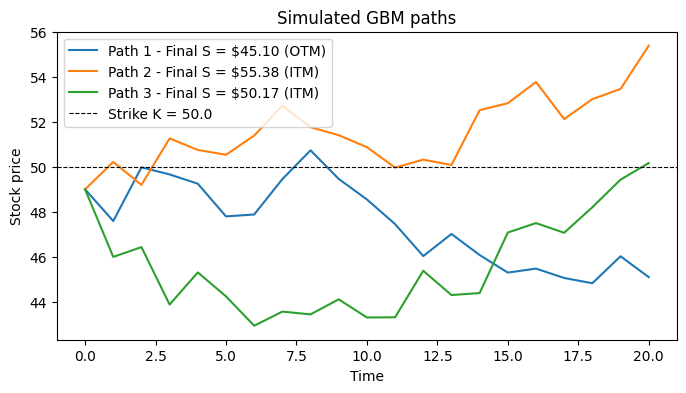

In [10]:
def simulate_gbm_book(S0, r, sigma, T, M, I,  seed=1):
    if seed is not None:
        npr.seed(seed)
    dt = T / M
    S = np.zeros((M + 1, I))
    S[0] = S0
    sn = npr.standard_normal((M + 1, I))

    for t in range(1, M + 1):
        S[t] = S[t - 1] * np.exp(
            (r - 0.5 * sigma ** 2) * dt
            + sigma * np.sqrt(dt) * sn[t]
        )
    return S


# generate 3 trajectories for illustration
S_3sim = simulate_gbm_book(S0=S0, r=0.05, sigma=sigma, T=T, M =M, I=3)

plt.figure(figsize=(8, 4))

for i in range(3):
    final_S = S_3sim[-1, i]
    label = f"Path {i+1} - Final S = ${final_S:.2f} ({'ITM' if final_S > K else 'OTM'})"
    plt.plot(S_3sim[:, i], label=label)

plt.axhline(K, color='black', linestyle='--', linewidth=0.8, label=f"Strike K = {K}")
plt.xlabel("Time")
plt.ylabel("Stock price")
plt.title("Simulated GBM paths")
plt.legend()
plt.show()

## 5. Delta Hedging Simulation

We consider a short position in 100,000 European call options and hedge it dynamically by trading the underlying stock.

At each weekly rebalancing date, the hedger:

1. recomputes the Black-Scholes delta,
2. adjusts the stock position to remain delta-neutral,
3. updates the cumulative hedging cost including financing.

The cumulative hedging cost is tracked recursively through time as shares are bought or sold and interest is accrued on the outstanding cost base.

### Net hedging cost

At maturity, the relevant quantity is the **net hedging cost**, defined as:

$$
\text{Net Cost}
=
C_T
-
\Delta_T S_T N
+
\max(S_T-K,0)\,N
$$

where:
where:
- $C_T$ is the final cumulative hedging cost,
- $\Delta_T S_T N$ represents the value of the final stock position,
- $\max(S_T - K, 0)\,N$ represents the payoff of the call option.

### Link to the Black-Scholes price

The Black-Scholes price can be interpreted as the expected replication cost of the option.
Therefore, across many simulated paths, the average net hedging cost should be close to the Black-Scholes premium.

In [11]:
def hedge_simulation(path , K, r, sigma, T, M, n_options=100_000):
    dt = T / M
    results = []

    cumulative_cost = 0
    delta_old = 0

    for t in range(M + 1):
        S_t = path[t]
        T_remaining = T - t * dt

        if T_remaining <= 0:
            delta_new = 1.0 if S_t > K else 0.0
        else:
            delta_new = delta(S_t, K, T_remaining, r, sigma)

        shares_purchased = (delta_new - delta_old) * n_options
        cost_shares = shares_purchased * S_t
        cumulative_cost = cumulative_cost + cost_shares      # invest first
        interest_cost = cumulative_cost * r * dt             # interest on the new position

        results.append({
            "week":             t,
            "stock_price":      S_t,
            "delta":            round(delta_new, 3),
            "shares_purchased": round(shares_purchased),
            "cost_shares":      round(cost_shares / 1000, 1),
            "cumulative_cost":  round(cumulative_cost / 1000, 1),
            "interest_cost":    round(interest_cost / 1000, 1)
        })
        delta_old = delta_new
        cumulative_cost = cumulative_cost + interest_cost    # carry interest into next week

    return pd.DataFrame(results)

## 6. Replication of Hull Table 19.2

We validate our implementation against Hull (2022), Table 19.2 — an ITM scenario
where the stock finishes at **57.25 USD** and the total hedging cost is **263,300 USD**.

Running our function on the exact price path from the book lets us verify
that the week-by-week numbers match.

In [12]:
# exact price path from Hull (2022), Table 19.2
S_test = np.array([49.00, 48.12, 47.37, 50.25, 51.75, 53.12, 53.00, 51.87,
                     51.38, 53.00, 49.88, 48.50, 49.88, 50.37, 52.13, 51.88,
                     52.87, 54.87, 54.62, 55.87, 57.25])

sim_test = hedge_simulation(path=S_test, K=K, r=r, sigma=sigma, T=20/52, M=M)
print(f"Total hedging cost: ${sim_test['cumulative_cost'].iloc[-1] * 1000:,.0f}  (Hull: $263,300)")
sim_test

Total hedging cost: $5,263,200  (Hull: $263,300)


,week,stock_price,delta,shares_purchased,cost_shares,cumulative_cost,interest_cost
0,0,49.00,0.522,52160,2555.9,2555.9,2.5
1,1,48.12,0.458,-6359,-306.0,2252.3,2.2
2,2,47.37,0.400,-5798,-274.7,1979.8,1.9
3,3,50.25,0.596,19626,986.2,2967.9,2.9
4,4,51.75,0.693,9667,500.3,3471.0,3.3
5,5,53.12,0.774,8087,429.6,3903.9,3.8
6,6,53.00,0.771,-253,-13.4,3894.3,3.7
7,7,51.87,0.706,-6514,-337.9,3560.1,3.4
8,8,51.38,0.674,-3196,-164.2,3399.3,3.3
9,9,53.00,0.787,11234,595.4,3998.0,3.8


## 7. Path Dependency of Hedging Costs

Although the **average** hedging cost converges to the Black-Scholes price,  
the cost along the way varies significantly depending on the trajectory.

The chart below shows the evolution of the cumulative hedging cost for our 3 simulated paths.  
It illustrates a key intuition:

- A path that ends **ITM** (delta → 1) requires holding many shares → high cumulative cost
- A path that ends **OTM** (delta → 0) requires unwinding the position → lower cumulative cost

The **net cost** (after accounting for the share portfolio and option payoff) is what converges  
to the Black-Scholes price across many simulations.

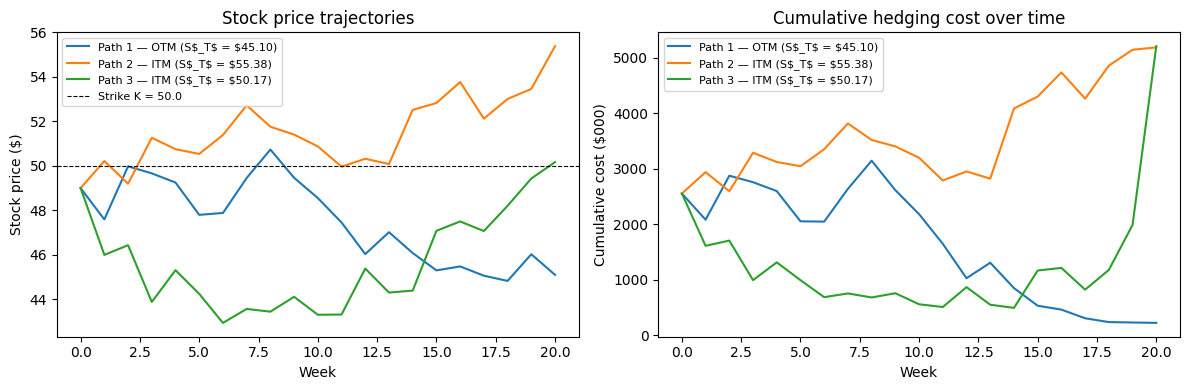

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i in range(3):
    path_i = S_3sim[:, i]
    sim_i = hedge_simulation(path=path_i, K=K, r=r, sigma=sigma, T=T, M=M)
    final_S = path_i[-1]
    outcome = 'ITM' if final_S > K else 'OTM'
    label = f"Path {i+1} — {outcome} (S$_T$ = ${final_S:.2f})"

    # stock price trajectories
    axes[0].plot(path_i, label=label)

    # cumulative hedging cost
    axes[1].plot(sim_i["cumulative_cost"], label=label)

axes[0].axhline(K, color='black', linestyle='--', linewidth=0.8, label=f'Strike K = {K}')
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Stock price ($)')
axes[0].set_title('Stock price trajectories')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Week')
axes[1].set_ylabel('Cumulative cost ($000)')
axes[1].set_title('Cumulative hedging cost over time')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 8. Monte Carlo Analysis

We now simulate **10,000 independent GBM paths** and apply the discrete hedging strategy to each of them.

For every path, we compute the final **net hedging cost** of the short call position.
This gives a distribution of hedging outcomes rather than a single pathwise result.

### What we expect

The average net hedging cost should be close to the Black-Scholes benchmark:

$$
\frac{1}{I}\sum_{i=1}^{I}\text{Net Cost}^{(i)}
\approx
C_{BS}\times N
$$

where $I$ is the number of simulated paths.

The dispersion around this average reflects the residual hedging error induced by **discrete rebalancing**.
This error is related to the option's gamma and decreases as the hedging frequency increases.

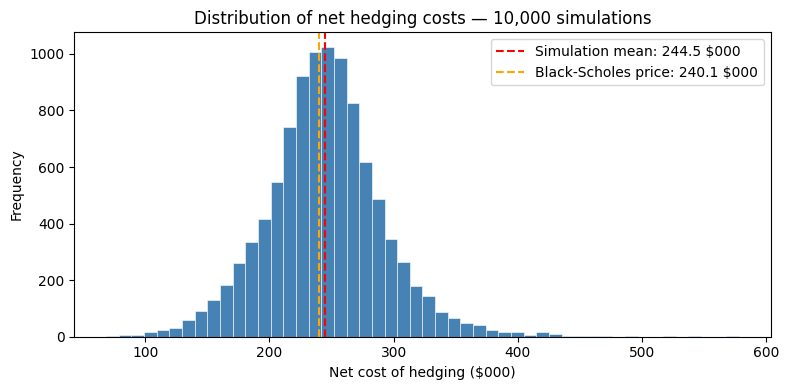

Black-Scholes price (per option): $2.4005
Black-Scholes total (x100,000): $240.1k
Simulation mean: $244.5k
Simulation std: $47.4k
Relative error: 1.84%


In [16]:
I = 10000
paths = simulate_gbm_book(S0=S0, r=r, sigma=sigma, T=T, M=M, I=I)

hedging_costs = []

for i in range(I):
    path_i = paths[:, i]

    sim = hedge_simulation(
        path=path_i, K=K, r=r, sigma=sigma, T=T, M=M, n_options=n_options
    )

    final_S = paths[-1, i]

    delta_final = sim["delta"].iloc[-1]
    shares_held = delta_final * n_options
    portfolio_value = shares_held * final_S / 1000
    payoff = np.maximum(final_S - K, 0) * n_options / 1000

    net_cost = sim["cumulative_cost"].iloc[-1] - portfolio_value + payoff
    hedging_costs.append(net_cost)

hedging_costs = np.array(hedging_costs)

# Black-Scholes theoretical price
bs_price1 = bs_price(S=S0, K=K, T=T, r=r, sigma=sigma)
bs_total = bs_price1 * n_options / 1000

# plot
plt.figure(figsize=(8, 4))
plt.hist(hedging_costs, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
plt.axvline(np.mean(hedging_costs), color='red', linestyle='--',
            label=f'Simulation mean: {np.mean(hedging_costs):.1f} $000')
plt.axvline(bs_total, color='orange', linestyle='--',
            label=f'Black-Scholes price: {bs_total:.1f} $000')
plt.xlabel('Net cost of hedging ($000)')
plt.ylabel('Frequency')
plt.title(f'Distribution of net hedging costs — {I:,} simulations')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Black-Scholes price (per option): ${bs_price1:.4f}")
print(f"Black-Scholes total (x{n_options:,}): ${bs_total:.1f}k")
print(f"Simulation mean: ${np.mean(hedging_costs):.1f}k")
print(f"Simulation std: ${np.std(hedging_costs):.1f}k")
print(f"Relative error: {abs(np.mean(hedging_costs) - bs_total) / bs_total * 100:.2f}%")

## 9. Conclusion

This notebook illustrates the Black-Scholes replication idea from two complementary angles.

First, the Hull-style pathwise analysis shows how a delta hedge is implemented in practice through a sequence of stock trades and financing adjustments.

Second, the Monte Carlo analysis shows that, across many simulated GBM paths, the **average net hedging cost** is close to the **Black-Scholes price**.

The main conclusion is therefore:

- the Black-Scholes price can be interpreted as the theoretical replication cost of the option,
- discrete delta hedging reproduces this value on average,
- but individual outcomes differ because rebalancing is performed only at discrete dates rather than continuously.

The remaining dispersion in hedging outcomes is the residual risk induced by discrete hedging.